SPIM v0 simulation
==================

In [33]:
import copy
import inspect

import numpy as np
import scipy
import matplotlib.pyplot as plt

from optiland.optic import Optic
from optiland import optimization
from optiland.materials import MaterialCatalog
from optiland.fileio import load_zemax_file
from optiland.analysis import SpotDiagram
from optiland import physical_apertures

# Illumination arm schematic & components

![title](illumination_path.png)


### Optical elements

- __Multimode fiber__: 50/125 μm, NA 0.2 (OM4 telecom multimode fiber)
- __Fiber collimator__: F8.0, D4.0 
- __Beam expander 1st lens__: F30, Thorlabs AC254-030-A
- __Beam expander 2nd lens__: F50, Thorlabs AC254-050-A

- __Cylindrical lens__: F75, Thorlabs LJ1703RM-A
- __Scan lens__: F30, Thorlabs AC254-030-A
- __Tube lens__: F50, Thorlabs AC254-050-A
- __Illumination objective__: F45 (analogue of 4X Olympus Plan Achromat Objective, 0.10 NA)

### Elements loading

In [2]:
lens_f30 = load_zemax_file('zemax/AC254-030-A-Zemax-ZMX.zmx')
lens_f45 = load_zemax_file('zemax/AC254-045-A-Zemax-ZMX.zmx')
lens_f50 = load_zemax_file('zemax/AC254-050-A-Zemax-ZMX.zmx')
lens_f100 = load_zemax_file('zemax/AC254-100-A-Zemax-ZMX.zmx')
lens_f75_cyl = load_zemax_file('zemax/LJ1703RM-A-Zemax-ZMX.zmx')

╒════╤═════════════════╤═══════════╤══════════╤═════════════╤════════════╤═════════╤═════════════════╕
│    │ Type            │ Comment   │   Radius │   Thickness │ Material   │   Conic │   Semi-aperture │
╞════╪═════════════════╪═══════════╪══════════╪═════════════╪════════════╪═════════╪═════════════════╡
│  0 │ Planar          │           │   inf    │    inf      │ Air        │       0 │       11.43     │
│  1 │ Stop - Standard │           │    20.89 │     12      │ N-BAF10    │       0 │       11.43     │
│  2 │ Standard        │           │   -16.73 │      2      │ N-SF6HT    │       0 │        8.79574  │
│  3 │ Standard        │           │   -79.8  │     21.6876 │ Air        │       0 │        8.46829  │
│  4 │ Planar          │           │   inf    │    nan      │ Air        │       0 │        0.205374 │
╘════╧═════════════════╧═══════════╧══════════╧═════════════╧════════════╧═════════╧═════════════════╛



(<Figure size 1000x400 with 1 Axes>, <Axes: xlabel='Z [mm]', ylabel='Y [mm]'>)

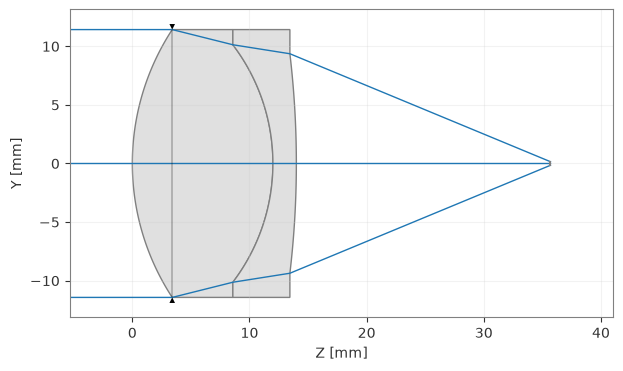

In [3]:
lens_f30.info()
lens_f30.draw()

### Custom aspheric fiber collimator lens

╒════╤═════════════════════╤═══════════╤═══════════╤═════════════╤════════════╤═══════════╤═════════════════╕
│    │ Type                │ Comment   │    Radius │   Thickness │ Material   │     Conic │   Semi-aperture │
╞════╪═════════════════════╪═══════════╪═══════════╪═════════════╪════════════╪═══════════╪═════════════════╡
│  0 │ Planar              │           │ inf       │     inf     │ Air        │  0        │         4       │
│  1 │ Planar              │           │ inf       │       3.434 │ D-ZK3      │  0        │         4       │
│  2 │ Stop - Even Asphere │           │  -4.63812 │       5     │ Air        │ -0.925521 │         4       │
│  3 │ Planar              │           │ inf       │     nan     │ Air        │  0        │         1.48844 │
╘════╧═════════════════════╧═══════════╧═══════════╧═════════════╧════════════╧═══════════╧═════════════════╛
╒═══════════╤══════╤══════════╤══════════╤═══════════╤════════════╤══════╤══════╤══════╕
│ Surface   │   c0 │       c1 │

/var/folders/_n/x6kt66zd1p1bt5_fbt2qnm6c0000gn/T/ipykernel_13827/3034917694.py:3: DeprecationWarning: Optic.set_material is deprecated and will be removed in v0.7.0; use optic.updater.set_material() instead.
  lens_f8_as.set_material(material=MaterialCatalog("cdgm").get("D-ZK3"),
/var/folders/_n/x6kt66zd1p1bt5_fbt2qnm6c0000gn/T/ipykernel_13827/3034917694.py:9: DeprecationWarning: Optic.update is deprecated and will be removed in v0.7.0; use optic.updater.update() instead.
  lens_f8_as.update()


(<Figure size 1000x400 with 1 Axes>, <Axes: xlabel='Z [mm]', ylabel='Y [mm]'>)

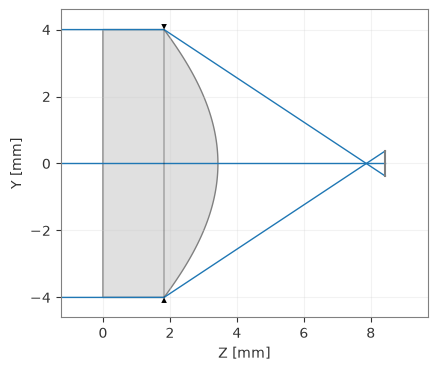

In [4]:
lens_f8_as = load_zemax_file('zemax/354240-Zemax-ZMX.zmx')

lens_f8_as.set_material(material=MaterialCatalog("cdgm").get("D-ZK3"),
                        surface_number=2)
lens_f8_as.surfaces.remove(1)
lens_f8_as.surfaces.remove(3)
lens_f8_as.surfaces.remove(3)
lens_f8_as.updater.flip()
lens_f8_as.update()

lens_f8_as.info()
lens_f8_as.draw()

# Optical schematic simulation

## Fiber collimation

Output marginal ray angle 0.005
╒════╤═════════════════════╤═══════════╤═══════════╤═════════════╤════════════╤═══════════╤═════════════════╕
│    │ Type                │ Comment   │    Radius │   Thickness │ Material   │     Conic │   Semi-aperture │
╞════╪═════════════════════╪═══════════╪═══════════╪═════════════╪════════════╪═══════════╪═════════════════╡
│  0 │ Planar              │           │ inf       │      6.2    │ Air        │  0        │        0        │
│  1 │ Planar              │           │ inf       │      3.434  │ D-ZK3      │  0        │        1.26557  │
│  2 │ Stop - Even Asphere │           │  -4.63812 │     20      │ Air        │ -0.925521 │        1.70535  │
│  3 │ Standard            │           │  20.89    │     12      │ N-BAF10    │  0        │        1.42066  │
│  4 │ Standard            │           │ -16.73    │      2      │ N-SF6HT    │  0        │        0.989332 │
│  5 │ Standard            │           │ -79.8     │     63      │ Air        │  0      

(<Figure size 1000x400 with 1 Axes>, <Axes: xlabel='Z [mm]', ylabel='Y [mm]'>)

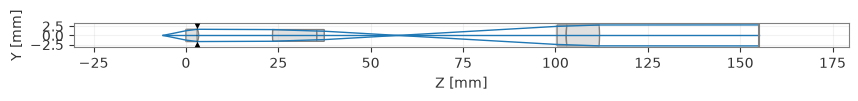

In [76]:
class FiberCollimator(Optic):
    def __init__(self, lens_collimation: Optic, lens_expander_1st:Optic, lens_expander_2nd:Optic,
                 d_coll:float, d_1st:float, d_2nd:float,   # distance from fiber to 1st lens and to 2nd lens
                 fiber_na:float=0.22): # numerical aperture of OM4 fiber        
        super().__init__(name='Fiber collimator')
        lens_2nd_flip = copy.deepcopy(lens_expander_2nd)
        lens_2nd_flip.updater.flip()
        # self.fiber_output_angle = fiber_na * 180 / np.pi * 2

        combined = lens_collimation + lens_expander_1st + lens_2nd_flip
        self.surfaces = combined.surfaces
        self.updater.set_thickness(d_coll, 0)
        self.updater.set_thickness(d_1st, 2)
        self.updater.set_thickness(d_2nd, 5)

        self.set_aperture(aperture_type="objectNA", value=fiber_na)
        self.wavelengths.add(value=0.510, is_primary=True)
        self.fields.set_type(field_type="angle")
        self.fields.add(y=0)


fc = FiberCollimator(lens_collimation=lens_f8_as,
                     lens_expander_1st=lens_f30,
                     lens_expander_2nd=lens_f50,
                     d_coll=6.2, d_1st=20.0, d_2nd=63.0,
                     fiber_na=0.2)

ya, ua = fc.paraxial.marginal_ray()
print(f"Output marginal ray angle {ua[-1, 0]:.3f}")

fc.info()
fc.draw()

## Light sheet formation

### Design

Front light sheet focal length 76.01541691375343
╒════╤═══════════════╤═══════════════╤══════════╤═════════════╤════════════╤═════════╤═════════════════╕
│    │ Type          │ Comment       │   Radius │   Thickness │ Material   │   Conic │   Semi-aperture │
╞════╪═══════════════╪═══════════════╪══════════╪═════════════╪════════════╪═════════╪═════════════════╡
│  0 │ Planar        │               │   inf    │    inf      │ Air        │       0 │     1.5         │
│  1 │ Stop - Planar │ Aperture stop │   inf    │     10      │ Air        │       0 │     1.5         │
│  2 │ Toroidal      │               │   inf    │     11.48   │ N-BK7      │       0 │     1.5         │
│  3 │ Toroidal      │               │   inf    │    110      │ Air        │       0 │    10.75        │
│  4 │ Standard      │               │   291.07 │      2.5    │ SF10       │       0 │     1.5         │
│  5 │ Standard      │               │    22.28 │      9      │ N-BAF10    │       0 │     1.49452     │
│  6 │

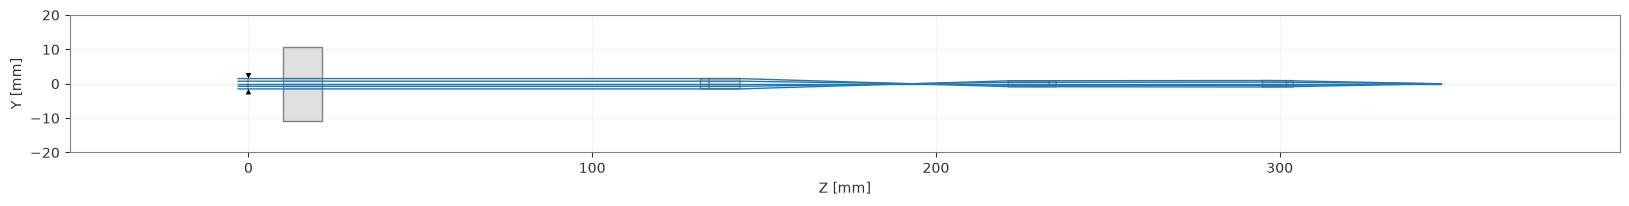

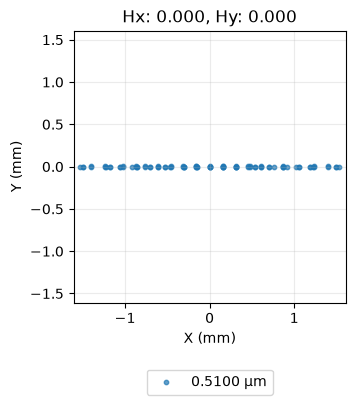

(<Figure size 1200x400 with 1 Axes>,
 [<Axes: title={'center': 'Hx: 0.000, Hy: 0.000'}, xlabel='X (mm)', ylabel='Y (mm)'>])

In [40]:
class LightSheet(Optic):
    def __init__(self, lens_cyl:Optic, lens_scan:Optic, lens_tube:Optic, lens_obj:Optic,
                 d_scan:float, d_tube:float, d_obj:float,
                 d_beam_iris_radius:float,
                 y_iris_radius:float, y_iris_position:float, place_y_iris:bool,
                 rotate_cyl_lens:bool=True):
        super().__init__()
        lens_scan_flipped = copy.deepcopy(lens_scan)
        lens_scan_flipped.updater.flip()
        lens_cyl_rotated  = copy.deepcopy(lens_cyl)

        def swap_toroid(optic, *idx):
            """Swap R_x and R_y for selected cylindric lens surfaces"""
            for i in idx:
                g = optic.surfaces[i].geometry
                g.__init__(g.cs, g.R_yz, g.R_rot, g.k_yz, g.coeffs_poly_y)
        if rotate_cyl_lens:
            swap_toroid(lens_cyl_rotated, 1, 2)

        combined = lens_cyl_rotated + lens_scan_flipped + lens_tube + lens_obj 
        self.surfaces = combined.surfaces 

        self.updater.set_thickness(d_scan, 2)
        if place_y_iris:
            self.updater.set_thickness(d_tube*y_iris_position, 5)
        else:
            self.updater.set_thickness(d_tube, 5)
        self.updater.set_thickness(d_obj, 8)
        self.updater.set_thickness(100, 11)

        # add aperture stop
        self.surfaces.add(index=1,
                          thickness=10,                        # distance from iris to tube lens
                          aperture=physical_apertures.RadialAperture(r_max=d_beam_iris_radius),  # iris radius, ligth sheet half high in mm
                          is_stop=True,
                          comment="Aperture stop")

        # add field stop
        if place_y_iris:
            self.surfaces.add(index=7,  # 6
                            thickness=d_tube - d_tube*y_iris_position,                        # distance from iris to tube lens
                            aperture=physical_apertures.RadialAperture(r_max=y_iris_radius),  # iris radius, ligth sheet half high in mm
                            is_stop=False,
                            comment="Y Iris")

        self.set_aperture(aperture_type="EPD", value=d_beam_iris_radius*2)
        self.wavelengths.add(value=0.51, is_primary=True)
        self.fields.set_type(field_type="angle")
        self.fields.add(y=0)                 # on-axis rays

        if rotate_cyl_lens:
            self.updater.image_solve()

# system side view
ls_yz = LightSheet(lens_cyl=lens_f75_cyl,
                lens_scan=lens_f50,
                lens_tube=lens_f30,
                lens_obj=lens_f45,
                d_scan=110,
                d_tube=68,
                d_obj=60,
                d_beam_iris_radius=5,
                y_iris_radius=2.5,
                y_iris_position=0.7,
                place_y_iris=False,
                rotate_cyl_lens=False)

# system top view
ls_xz = LightSheet(lens_cyl=lens_f75_cyl,
                lens_scan=lens_f50,
                lens_tube=lens_f30,
                lens_obj=lens_f45,
                d_scan=110,
                d_tube=78,
                d_obj=60,
                d_beam_iris_radius=1.5,
                y_iris_radius=0.5,
                y_iris_position=0.63,
                place_y_iris=False,
                rotate_cyl_lens=True)

f_ls = ls_xz.paraxial.f1()
print(f"Front light sheet focal length {f_ls}")

ls_xz.info()
ls_xz.draw(figsize=(20, 10),  num_rays=5, ylim=(-20, 20))

ls_sd = SpotDiagram(ls_xz, num_rings=5)
ls_sd.view()

### Elements positions optimization

In [7]:
# problem = optimization.OptimizationProblem()

# input_data = {"optic": ls_xz,
#               "surface_number": -1,
#               "Hx": 0,
#               "Hy": 0,
#               "num_rays": 5,
#               "wavelength": 0.55,
#               "distribution": "hexapolar"}

# problem.add_operand(operand_type="rms_spot_size",
#                     target=0,
#                     weight=1,
#                     input_data=input_data)

# # problem.add_variable(ls_xz, "thickness", surface_number=3, min_val=80, max_val=150)  # from cylindrical lens to scan lens
# problem.add_variable(ls_xz, "thickness", surface_number=6, min_val=10, max_val=50)  # from scan lens to tubus lens
# problem.add_variable(ls_xz, "thickness", surface_number=7, min_val=10, max_val=50)  

# problem.add_variable(ls_xz, "thickness", surface_number=10, min_val=50, max_val=100)  # from tubus lens to objective
# problem.add_variable(ls_xz, "thickness", surface_number=13, min_val=40, max_val=70)  # from objective to image plane

# problem.info()

In [8]:
# optimizer = optimization.OptimizerGeneric(problem)
# optimizer.optimize(tol=1e-6)

# problem.info()

In [9]:
# ls_xz.draw()

## Illumination light path assembly

### Schema

╒════╤═══════════════╤═══════════════╤════════════╤═════════════╤════════════╤═══════════╤═════════════════╕
│    │ Type          │ Comment       │     Radius │   Thickness │ Material   │     Conic │   Semi-aperture │
╞════╪═══════════════╪═══════════════╪════════════╪═════════════╪════════════╪═══════════╪═════════════════╡
│  0 │ Planar        │               │  inf       │      6.2    │ Air        │  0        │        0        │
│  1 │ Planar        │               │  inf       │      3.434  │ D-ZK3      │  0        │        1.68495  │
│  2 │ Even Asphere  │               │   -4.63812 │     20      │ Air        │ -0.925521 │        2.27047  │
│  3 │ Standard      │               │   20.89    │     12      │ N-BAF10    │  0        │        1.89143  │
│  4 │ Standard      │               │  -16.73    │      2      │ N-SF6HT    │  0        │        1.31717  │
│  5 │ Standard      │               │  -79.8     │     63      │ Air        │  0        │        1.24147  │
│  6 │ Standard    

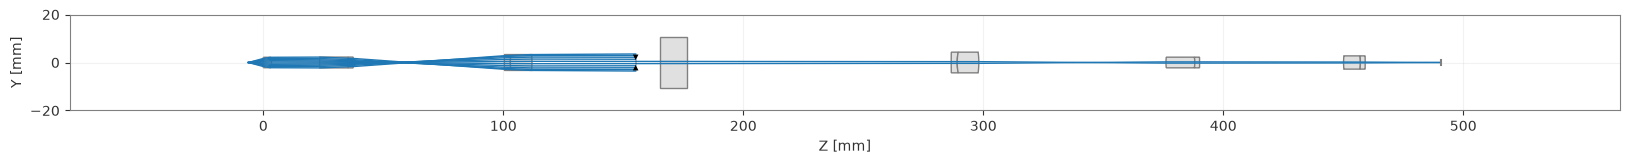

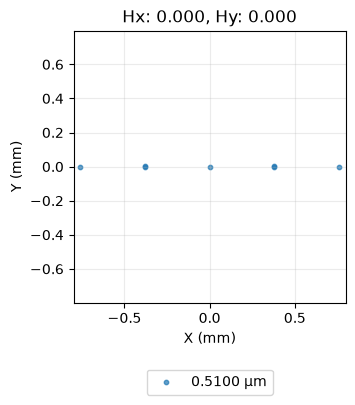

(<Figure size 1200x400 with 1 Axes>,
 [<Axes: title={'center': 'Hx: 0.000, Hy: 0.000'}, xlabel='X (mm)', ylabel='Y (mm)'>])

In [ ]:
def _pick(cls, kwargs):
    """kwargs selection for cls constructor"""
    names = set(inspect.signature(cls.__init__).parameters) - {"self"}
    return {k: v for k, v in kwargs.items() if k in names}

class IlluminationSPIM(Optic):
    def __init__(self, **kwargs):
        super().__init__(name='SPIM_illumination')
        fc = FiberCollimator(**_pick(FiberCollimator, kwargs))
        ls = LightSheet(**_pick(LightSheet, kwargs))

        self.surfaces = (fc + ls).surfaces
        self.surfaces[2].is_stop = False
        self.surfaces[9].is_stop = True

        self.set_aperture(aperture_type="EPD", value=kwargs["d_beam_iris_radius"]*2)
        self.fields.set_type(field_type="angle")
        self.fields.add(y=0)
        self.wavelengths.add(value=0.51, is_primary=True)
        


ill_spim_params =  {"lens_collimation":lens_f8_as,
                    "lens_expander_1st":lens_f30,
                    "lens_expander_2nd":lens_f50,
                    "d_coll":6.2,
                    "d_1st":20.0,
                    "d_2nd":63.0,
                    "fiber_na":0.1,
                    "lens_cyl":lens_f75_cyl,
                    "lens_scan":lens_f50,
                    "lens_tube":lens_f30,
                    "lens_obj":lens_f45,
                    "d_scan":110,
                    "d_tube":78,
                    "d_obj":60,
                    "d_beam_iris_radius":1,
                    "y_iris_radius":1,
                    "y_iris_position":0.63,
                    "place_y_iris":False,
                    "rotate_cyl_lens":True}

ill_arm = IlluminationSPIM(**ill_spim_params)
ill_arm.info()
ill_arm.updater.image_solve()
ill_arm.info()
ill_arm.draw(figsize=(20, 20), num_rays=10, ylim=(-20, 20))

ls_sd = SpotDiagram(ill_arm)
ls_sd.view()

### Optimization

In [138]:
ill_optim = IlluminationSPIM(**ill_spim_params)

problem = optimization.OptimizationProblem()

# fiber collimator output parallelism, two rays
problem.add_operand(operand_type="real_M", target=0, weight=100,
                    input_data={"optic": ill_optim, "surface_number": 8,
                    "Hx": 0, "Hy": 0, "Px": 0, "Py": 0.5, "wavelength": 0.51})
problem.add_operand(operand_type="real_M", target=0, weight=100,
                    input_data={"optic": ill_optim, "surface_number": 8,
                    "Hx": 0, "Hy": 0, "Px": 0, "Py": 0.25, "wavelength": 0.51})

# objective focus position, two rays
problem.add_operand(operand_type="real_y_intercept", target=0, weight=20,
                    input_data={"optic": ill_optim, "surface_number": -1,
                    "Hx": 0, "Hy": 0, "Px": 0, "Py": 0.25, "wavelength": 0.51})
problem.add_operand(operand_type="real_y_intercept", target=0, weight=20,
                    input_data={"optic": ill_optim, "surface_number": -1,
                    "Hx": 0, "Hy": 0, "Px": 0, "Py": 0.1, "wavelength": 0.51})


problem.add_variable(ill_optim, "thickness", surface_number=0, max_val=10)  # fiber output
problem.add_variable(ill_optim, "thickness", surface_number=5, max_val=80)  # beam expander
problem.add_variable(ill_optim, "thickness", surface_number=11, min_val=100, max_val=150)  # d_tube
problem.add_variable(ill_optim, "thickness", surface_number=14, min_val=50, max_val=80)  # d_tube
problem.add_variable(ill_optim, "thickness", surface_number=20, min_val=35, max_val=70)  # objective position

problem.info()

╒════╤════════════════════════╤═══════════════════╕
│    │   Merit Function Value │   Improvement (%) │
╞════╪════════════════════════╪═══════════════════╡
│  0 │                7.17075 │                 0 │
╘════╧════════════════════════╧═══════════════════╛
╒════╤══════════════════╤══════════╤══════════════╤══════════════╤══════════╤═══════════════╤═════════╤═════════╤════════════════╕
│    │ Operand Type     │   Target │ Min. Bound   │ Max. Bound   │   Weight │   Eff. Weight │   Value │   Delta │   Contrib. [%] │
╞════╪══════════════════╪══════════╪══════════════╪══════════════╪══════════╪═══════════════╪═════════╪═════════╪════════════════╡
│  0 │ real M           │        0 │              │              │      100 │           100 │   0.002 │   0.002 │           0.48 │
│  1 │ real M           │        0 │              │              │      100 │           100 │   0.002 │   0.002 │           0.35 │
│  2 │ real y intercept │        0 │              │              │       20 │        

╒════╤════════════════════════╤═══════════════════╕
│    │   Merit Function Value │   Improvement (%) │
╞════╪════════════════════════╪═══════════════════╡
│  0 │              0.0154886 │            99.784 │
╘════╧════════════════════════╧═══════════════════╛
╒════╤══════════════════╤══════════╤══════════════╤══════════════╤══════════╤═══════════════╤═════════╤═════════╤════════════════╕
│    │ Operand Type     │   Target │ Min. Bound   │ Max. Bound   │   Weight │   Eff. Weight │   Value │   Delta │   Contrib. [%] │
╞════╪══════════════════╪══════════╪══════════════╪══════════════╪══════════╪═══════════════╪═════════╪═════════╪════════════════╡
│  0 │ real M           │        0 │              │              │      100 │           100 │  -0     │  -0     │           3.84 │
│  1 │ real M           │        0 │              │              │      100 │           100 │   0.001 │   0.001 │          23.12 │
│  2 │ real y intercept │        0 │              │              │       20 │        

/Users/wisstock/miniconda3/envs/optiland/lib/python3.14/site-packages/optiland/optimization/optimizer/scipy/base.py:110: OptimizeWarning: Unknown solver options: disp
  result = optimize.minimize(


(<Figure size 2000x2000 with 1 Axes>, <Axes: xlabel='Z [mm]', ylabel='Y [mm]'>)

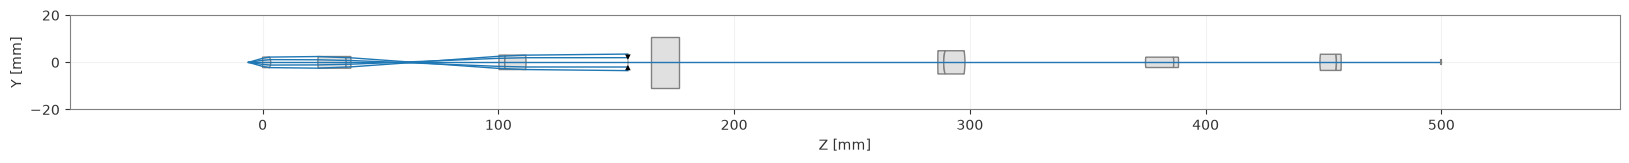

In [139]:
optimizer = optimization.OptimizerGeneric(problem)
optimizer.optimize(tol=1e-6)

problem.info()
ill_optim.draw(figsize=(20, 20), num_rays=5, ylim=(-20, 20))